<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/CSP_KAN_UNet_REFUGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSP-KAN-UNet — Single-decoder U-KAN with **triple-attention (Channel+Spatial+Pixel)** decoder

REFUGE optic disc & cup segmentation. Inspired by **Preity et al., "SA-U-KAN: Spatial Attention Guided
Kolmogorov–Arnold Networks for Optic Disc and Cup Segmentation," IEEE Sensors Letters, 2026**, with a
twist on the decoder.

## The architecture (exactly as agreed)
- **Encoder — plain Y-Net.** DoubleConv stages 64/128/256/512 + MaxPool. **No attention** — same simple
  encoder as your Y-Net.
- **Bottleneck — tokenized KAN** (like the paper): efficient-KAN blocks (base-SiLU + cubic B-spline,
  3 KANLinear + depthwise-conv sublayers, LayerNorm, residual). Verbatim math from your U-KAN notebook.
- **Decoder — SINGLE decoder, the twist.** One decoder (no dual pipeline). Each up-stage passes its
  fused feature through a **triple-attention block = Channel → Spatial → Pixel** attention:
  - **Channel** ("what"): global avg+max pool → shared MLP → sigmoid → scale channels (CBAM channel).
  - **Spatial** ("where"): avg+max across channels → concat → 7×7 conv → sigmoid → scale positions (CBAM spatial).
  - **Pixel** ("per-pixel gate"): 1×1 conv → sigmoid → element-wise gate (PAN-style pixel attention).
- **Output:** a single 3-class head → `[bg, disc, cup]` in one forward pass.

## Why this is worth trying
Your KAN-bottleneck Y-Net *lost* to the plain conv Y-Net (mean 0.8729 vs 0.9055). The cup was the
bottleneck (recall 0.865 > precision 0.795 → over-segmentation). Stacking channel+spatial+pixel
attention on the decoder targets exactly that: channel picks the useful feature maps, spatial localises
the disc/cup region, pixel sharpens the boundary per-pixel. KAN bottleneck keeps the paper's interpretable
nonlinear modelling.

| Prior run (REFUGE, 256², test) | Disc Dice | Cup Dice | Mean(disc,cup) |
|---|---|---|---|
| Conv Y-Net | 0.9618 (whole-disc) | 0.8491 | 0.9055 |
| KAN-bottleneck Y-Net | 0.9374 (whole-disc) | 0.8083 | 0.8729 |
| **CSP-KAN-UNet (this)** | ? | ? | **?** |

Runs top-to-bottom on Kaggle (dual T4) by default; one flag switches to Colab.

## Cell 1 — Imports & environment

In [ ]:
import os, math, random, time, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", DEVICE, "| GPUs:", torch.cuda.device_count())

Torch: 2.11.0+cu128 | Device: cuda | GPUs: 1


## Cell 1b — Kaggle dataset uploader & downloader

Run this once, right before Cell 2 (Config). Works on Colab (uses the file-upload dialog) and on Kaggle/plain Jupyter (drag `kaggle.json` into the file browser first, then run). Downloads `arnavjain1/glaucoma-datasets` and unzips it into a target folder that Cell 2's `CFG.DATASET_ROOT` logic now checks for automatically.

In [ ]:
import os

DOWNLOAD_TARGET = "/content/glaucoma-datasets" if os.path.isdir("/content") else "/kaggle/working/glaucoma-datasets"

if os.path.isdir(DOWNLOAD_TARGET) and len(os.listdir(DOWNLOAD_TARGET)) > 0:
    print(f"{DOWNLOAD_TARGET} already exists, skipping download.")
    print("Contents:", os.listdir(DOWNLOAD_TARGET))
else:
    # 1. Get kaggle.json onto disk (Kaggle account -> Settings -> API -> Create New Token)
    try:
        from google.colab import files
        print("Upload your kaggle.json now:")
        uploaded = files.upload()  # select kaggle.json in the file picker
    except ImportError:
        # Not Colab (e.g. running on Kaggle itself, or a plain Jupyter server).
        # Drag-and-drop kaggle.json into this notebook's file browser panel
        # first, then just re-run this cell.
        assert os.path.exists("kaggle.json"), (
            "No kaggle.json found in the working directory. Drag-and-drop it "
            "into the file browser here, then re-run this cell."
        )

    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    if os.path.exists("kaggle.json"):
        os.replace("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

    !pip install -q kaggle

    # 2. Download + unzip into the target path CFG now checks for
    os.makedirs(DOWNLOAD_TARGET, exist_ok=True)
    !kaggle datasets download -d arnavjain1/glaucoma-datasets -p {DOWNLOAD_TARGET} --unzip

    print("\nDownload complete. Contents of", DOWNLOAD_TARGET, ":")
    print(os.listdir(DOWNLOAD_TARGET))


Upload your kaggle.json now:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [01:08<00:00, 87.2MB/s]


Download complete. Contents of /content/glaucoma-datasets :
['ORIGA', 'REFUGE', 'G1020', 'models']


## Cell 2 — Config (the cell you edit)

Point `DATA_ROOT` at REFUGE. Masks expected as 3-class: `0=bg, 1=disc(rim), 2=cup`. This is a **single
3-class model**, so unlike the dual-decoder notebooks there is one head and one loss.

In [ ]:
class CFG:
    # ---- data (same setup as your earlier Kaggle notebooks) ----
    # On Kaggle: '+ Add Data' -> search "glaucoma-datasets" (by arnavjain1) -> Add.
    # NOTE: /kaggle/input can EXIST but be EMPTY if no dataset has been attached yet -
    # checking isdir() alone wrongly treated that as "found" and skipped the downloaded-
    # data branches below. Now also requires it to be non-empty.
    if os.path.isdir("/kaggle/input") and len(os.listdir("/kaggle/input")) > 0:
        DATASET_ROOT = "/kaggle/input"             # Kaggle mount (via + Add Data)
    elif os.path.isdir("/content/glaucoma-datasets"):
        DATASET_ROOT = "/content/glaucoma-datasets" # Colab download
    elif os.path.isdir("/kaggle/working/glaucoma-datasets"):
        DATASET_ROOT = "/kaggle/working/glaucoma-datasets" # Kaggle-side kaggle-API download
    else:
        DATASET_ROOT = "data"                      # local
    DATASET_NAME = "REFUGE"                         # which sub-dataset to use
    USE_CROPPED  = False                            # False = full Images/Masks (comparable to Y-Net 0.9055);
                                                    # True = pre-cropped disc ROI (higher cup Dice, NOT comparable)
    IMG_SIZE   = 256                               # divisible by 16; 256 matches prior runs
    NUM_WORKERS= 2
    NUM_CLASSES= 3                                 # bg, disc, cup

    # encoder / bottleneck
    ENC_CH     = (64, 128, 256, 512)
    BOTT_DIM   = 512
    KAN_DEPTH  = 2
    GRID_SIZE  = 5
    SPLINE_ORDER = 3

    # decoder triple attention toggles (all ON = the twist; flip for ablation)
    USE_CHANNEL = True
    USE_SPATIAL = True
    USE_PIXEL   = True

    # loss  (single 3-class head; cup up-weighted; Focal-Tversky on the cup class)
    W_CE, W_DICE, W_TVERSKY = 0.4, 0.3, 0.3
    CLASS_WEIGHTS = [1.0, 1.0, 1.5]                # bg, disc, cup  -> push cup
    TVERSKY_ALPHA, TVERSKY_BETA = 0.3, 0.7        # beta>alpha -> penalise FN -> recall
    FT_GAMMA   = 0.75
    TVERSKY_CLASSES = [1, 2]                       # apply FT to disc and cup foreground

    # train
    EPOCHS=150; BATCH_SIZE=8; LR=1e-3; WD=1e-4; PATIENCE=25; AMP=True

    # eval
    USE_TTA=True; USE_POSTPROC=True; CKPT_PATH="csp_kan_unet_best.pt"

cfg = CFG()
print("DATASET_ROOT:", cfg.DATASET_ROOT, "| DATASET_NAME:", cfg.DATASET_NAME,
      "| USE_CROPPED:", cfg.USE_CROPPED)
print("IMG_SIZE:", cfg.IMG_SIZE, "| attn C/S/P:",
      cfg.USE_CHANNEL, cfg.USE_SPATIAL, cfg.USE_PIXEL, "| KAN_DEPTH:", cfg.KAN_DEPTH)

DATASET_ROOT: /content/glaucoma-datasets | DATASET_NAME: REFUGE | USE_CROPPED: False
IMG_SIZE: 256 | attn C/S/P: True True True | KAN_DEPTH: 2


## Cell 3 — efficient-KAN blocks (verbatim math from your U-KAN notebook)

`KANLinear` = SiLU base branch + cubic B-spline branch with a learnable grid. `KANLayer` = 3 KANLinear
sublayers each followed by a depthwise conv. `KANBlock` = LayerNorm → KANLayer → residual.

In [ ]:
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 scale_noise=0.1, scale_base=1.0, scale_spline=1.0,
                 enable_standalone_scale_spline=True,
                 base_activation=nn.SiLU, grid_range=(-1, 1)):
        super().__init__()
        self.in_features = in_features; self.out_features = out_features
        self.grid_size = grid_size; self.spline_order = spline_order
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = ((torch.arange(-spline_order, grid_size + spline_order + 1) * h
                 + grid_range[0]).expand(in_features, -1).contiguous())
        self.register_buffer("grid", grid)
        self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = nn.Parameter(torch.empty(out_features, in_features, grid_size + spline_order))
        if enable_standalone_scale_spline:
            self.spline_scaler = nn.Parameter(torch.empty(out_features, in_features))
        self.scale_noise = scale_noise; self.scale_base = scale_base; self.scale_spline = scale_spline
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = ((torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 0.5)
                     * self.scale_noise / self.grid_size)
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(self.grid.T[self.spline_order:-self.spline_order], noise))
            if self.enable_standalone_scale_spline:
                nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x):
        grid = self.grid; x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = ((x - grid[:, :-(k + 1)]) / (grid[:, k:-1] - grid[:, :-(k + 1)]) * bases[:, :, :-1]) \
                  + ((grid[:, k + 1:] - x) / (grid[:, k + 1:] - grid[:, 1:(-k)]) * bases[:, :, 1:])
        return bases.contiguous()

    def curve2coeff(self, x, y):
        A = self.b_splines(x).transpose(0, 1); B = y.transpose(0, 1)
        sol = torch.linalg.lstsq(A, B).solution
        return sol.permute(2, 0, 1).contiguous()

    @property
    def scaled_spline_weight(self):
        s = self.spline_scaler.unsqueeze(-1) if self.enable_standalone_scale_spline else 1.0
        return self.spline_weight * s

    def forward(self, x):
        orig = x.shape; x = x.reshape(-1, self.in_features)
        base_out = F.linear(self.base_activation(x), self.base_weight)
        spline_out = F.linear(self.b_splines(x).view(x.size(0), -1),
                              self.scaled_spline_weight.view(self.out_features, -1))
        return (base_out + spline_out).reshape(*orig[:-1], self.out_features)


class DW_bn_relu(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)
        self.bn = nn.BatchNorm2d(dim); self.relu = nn.ReLU()
    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.relu(self.bn(self.dwconv(x)))
        return x.flatten(2).transpose(1, 2)


class KANLayer(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, grid_size=5, spline_order=3):
        super().__init__()
        hidden_features = hidden_features or in_features
        out_features = out_features or in_features
        self.fc1 = KANLinear(in_features, hidden_features, grid_size, spline_order)
        self.fc2 = KANLinear(hidden_features, out_features, grid_size, spline_order)
        self.fc3 = KANLinear(hidden_features, out_features, grid_size, spline_order)
        self.dwconv_1 = DW_bn_relu(hidden_features)
        self.dwconv_2 = DW_bn_relu(hidden_features)
        self.dwconv_3 = DW_bn_relu(hidden_features)
    def forward(self, x, H, W):
        x = self.dwconv_1(self.fc1(x), H, W)
        x = self.dwconv_2(self.fc2(x), H, W)
        x = self.dwconv_3(self.fc3(x), H, W)
        return x


class KANBlock(nn.Module):
    def __init__(self, dim, grid_size=5, spline_order=3):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layer = KANLayer(dim, dim, dim, grid_size, spline_order)
    def forward(self, x, H, W):
        return x + self.layer(self.norm(x), H, W)

## Cell 4 — Attention modules + the triple-attention decoder block

`ChannelAttention` (CBAM channel), `SpatialAttention` (CBAM spatial), `PixelAttention` (1×1 conv gate).
`TripleAttention` runs them as a **channel → spatial → pixel** cascade; each sub-block is individually
toggleable from CFG for ablation. `DoubleConv` is the plain Y-Net conv block.

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)


class ChannelAttention(nn.Module):
    "CBAM channel gate: shared MLP over avg- and max-pooled channel descriptors."
    def __init__(self, ch, r=16):
        super().__init__()
        h = max(ch // r, 4)
        self.mlp = nn.Sequential(nn.Linear(ch, h), nn.ReLU(inplace=True), nn.Linear(h, ch))
    def forward(self, x):
        b, c, _, _ = x.shape
        avg = self.mlp(F.adaptive_avg_pool2d(x, 1).view(b, c))
        mx  = self.mlp(F.adaptive_max_pool2d(x, 1).view(b, c))
        w = torch.sigmoid(avg + mx).view(b, c, 1, 1)
        return x * w


class SpatialAttention(nn.Module):
    "CBAM spatial gate: [avg;max] over channels -> 7x7 conv -> sigmoid."
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k // 2, bias=False)
    def forward(self, x):
        avg = torch.mean(x, 1, keepdim=True)
        mx, _ = torch.max(x, 1, keepdim=True)
        w = torch.sigmoid(self.conv(torch.cat([avg, mx], 1)))
        return x * w


class PixelAttention(nn.Module):
    "PAN-style per-pixel gate: 1x1 conv -> sigmoid, element-wise."
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 1, bias=True)
    def forward(self, x):
        return x * torch.sigmoid(self.conv(x))


class TripleAttention(nn.Module):
    "Channel -> Spatial -> Pixel cascade; each toggleable for ablation."
    def __init__(self, ch, use_c=True, use_s=True, use_p=True):
        super().__init__()
        self.ca = ChannelAttention(ch) if use_c else nn.Identity()
        self.sa = SpatialAttention()   if use_s else nn.Identity()
        self.pa = PixelAttention(ch)   if use_p else nn.Identity()
    def forward(self, x):
        return self.pa(self.sa(self.ca(x)))

## Cell 5 — CSP-KAN-UNet model (plain encoder → KAN bottleneck → single triple-attention decoder → 3-class head)

`forward` returns one tensor `B×3×H×W`. Requires `IMG_SIZE` divisible by 16 (256 ✓).

In [ ]:
class CSPKANUNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        c1, c2, c3, c4 = cfg.ENC_CH
        self.pool = nn.MaxPool2d(2)
        # --- plain Y-Net encoder (no attention) ---
        self.enc1 = DoubleConv(3,  c1)
        self.enc2 = DoubleConv(c1, c2)
        self.enc3 = DoubleConv(c2, c3)
        self.enc4 = DoubleConv(c3, c4)
        # --- KAN bottleneck ---
        self.bott_in = nn.Conv2d(c4, cfg.BOTT_DIM, 3, padding=1)
        self.kan_blocks = nn.ModuleList(
            [KANBlock(cfg.BOTT_DIM, cfg.GRID_SIZE, cfg.SPLINE_ORDER) for _ in range(cfg.KAN_DEPTH)])
        self.bott_norm = nn.LayerNorm(cfg.BOTT_DIM)
        self.bott_out = nn.Conv2d(cfg.BOTT_DIM, c4 * 2, 3, padding=1)
        # --- single decoder with triple attention at each stage ---
        tri = lambda ch: TripleAttention(ch, cfg.USE_CHANNEL, cfg.USE_SPATIAL, cfg.USE_PIXEL)
        self.up4 = nn.ConvTranspose2d(c4 * 2, c4, 2, stride=2); self.dec4 = DoubleConv(c4 + c4, c4); self.att4 = tri(c4)
        self.up3 = nn.ConvTranspose2d(c4, c3, 2, stride=2);     self.dec3 = DoubleConv(c3 + c3, c3); self.att3 = tri(c3)
        self.up2 = nn.ConvTranspose2d(c3, c2, 2, stride=2);     self.dec2 = DoubleConv(c2 + c2, c2); self.att2 = tri(c2)
        self.up1 = nn.ConvTranspose2d(c2, c1, 2, stride=2);     self.dec1 = DoubleConv(c1 + c1, c1); self.att1 = tri(c1)
        self.head = nn.Conv2d(c1, cfg.NUM_CLASSES, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        # KAN bottleneck
        b = self.bott_in(self.pool(e4)); B, D, H, W = b.shape
        t = b.flatten(2).transpose(1, 2)
        for blk in self.kan_blocks: t = blk(t, H, W)
        t = self.bott_norm(t)
        b = self.bott_out(t.transpose(1, 2).view(B, D, H, W))
        # decoder + triple attention
        d = self.att4(self.dec4(torch.cat([self.up4(b), e4], 1)))
        d = self.att3(self.dec3(torch.cat([self.up3(d), e3], 1)))
        d = self.att2(self.dec2(torch.cat([self.up2(d), e2], 1)))
        d = self.att1(self.dec1(torch.cat([self.up1(d), e1], 1)))
        return self.head(d)


model = CSPKANUNet(cfg).to(DEVICE)
n = sum(p.numel() for p in model.parameters())
print(f"CSP-KAN-UNet | params: {n:,} (~{n/1e6:.1f}M)")
with torch.no_grad():
    y = model(torch.randn(1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE).to(DEVICE))
    print("output:", tuple(y.shape), "(expect B×3×H×W)")

CSP-KAN-UNet | params: 40,119,943 (~40.1M)
output: (1, 3, 256, 256) (expect B×3×H×W)


## Cell 6 — Dataset & loader (auto-discovery + REFUGE mask remap — same as your early Kaggle files)

Instead of hard-coding paths, this **walks `DATASET_ROOT`**, finds every image folder that has a sibling
mask folder inside `REFUGE`, and infers the split (train/val/test) from the path — robust to how the
Kaggle mirror lays things out. Set `USE_CROPPED` in Cell 2 to prefer the pre-cropped ROI folders.

**Mask encoding is handled correctly:** original REFUGE grayscale is `255=bg, 128=disc, 0=cup`, remapped
to `{0=bg, 1=disc, 2=cup}` (this matches your earlier notebooks; a naive white=cup mapping would be wrong).
If the official train/val/test folders aren't all present, it falls back to a deterministic 70/15/15 split.

In [ ]:
import glob, cv2
import torchvision.transforms.functional as TF

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

IMG_KEYS  = (["Images_Cropped", "images_cropped"] if cfg.USE_CROPPED else []) + \
            ["Images", "images", "Images_Square", "img"]
MASK_KEYS = (["Masks_Cropped", "masks_cropped"] if cfg.USE_CROPPED else []) + \
            ["Masks", "masks", "Masks_Square"]
EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

def list_images(d):
    fs = []
    for e in EXTS: fs += glob.glob(os.path.join(d, e))
    return sorted(fs)

def find_dataset_dirs(root, name):
    "Walk the tree; return (split, img_dir, mask_dir) triples inside the chosen dataset."
    triples = []
    for dirpath, dirnames, _ in os.walk(root):
        if name.lower() not in dirpath.lower(): continue
        if os.path.basename(dirpath) in IMG_KEYS and len(list_images(dirpath)) > 0:
            parent = os.path.dirname(dirpath)
            mask_dir = next((os.path.join(parent, mk) for mk in MASK_KEYS
                             if os.path.isdir(os.path.join(parent, mk))), None)
            if mask_dir is None:                       # masks one level up
                gp = os.path.dirname(parent)
                mask_dir = next((os.path.join(gp, mk) for mk in MASK_KEYS
                                 if os.path.isdir(os.path.join(gp, mk))), None)
            if mask_dir:
                low = dirpath.lower()
                split = ("train" if "train" in low else
                         "val"   if ("val" in low or "valid" in low) else
                         "test"  if "test" in low else "all")
                triples.append((split, dirpath, mask_dir))
    return triples

def build_pairs(img_dir, mask_dir):
    "Match each image to its mask by filename stem."
    masks = {}
    for p in list_images(mask_dir):
        masks.setdefault(os.path.splitext(os.path.basename(p))[0], p)
    pairs = []
    for ip in list_images(img_dir):
        stem = os.path.splitext(os.path.basename(ip))[0]
        if stem in masks: pairs.append((ip, masks[stem]))
    return pairs

def remap_mask(m):
    "REFUGE grayscale 255=bg,128=disc,0=cup -> {0=bg,1=disc,2=cup}; robust to other encodings."
    if m.ndim == 3: m = m[..., 0]
    u = set(np.unique(m).tolist()); out = np.zeros(m.shape, np.int64)
    if u <= {0, 1, 2}:
        out = m.astype(np.int64)                                    # already class indices
    elif u <= {0, 128, 255} or 128 in u:
        out[m == 255] = 0; out[(m > 0) & (m < 255)] = 1; out[m == 0] = 2   # 255=bg,128=disc,0=cup
    else:
        thr = sorted(u); out[m >= thr[-1]] = 0
        if len(thr) >= 3: out[(m > thr[0]) & (m < thr[-1])] = 1
        out[m <= thr[0]] = 2
    return out

class RefugeDS(Dataset):
    def __init__(self, pairs, size, train=False):
        self.pairs = pairs; self.size = size; self.train = train
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        ip, mp = self.pairs[i]
        image = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        mask = remap_mask(cv2.imread(mp, cv2.IMREAD_UNCHANGED)).astype(np.uint8)
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)
        img = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask.astype(np.int64))
        if self.train:
            if random.random() < 0.5: img = TF.hflip(img); mask = torch.flip(mask, [1])
            if random.random() < 0.5: img = TF.vflip(img); mask = torch.flip(mask, [0])
            if random.random() < 0.5:
                a = random.uniform(-20, 20)
                img = TF.rotate(img, a)
                mask = TF.rotate(mask.unsqueeze(0).float(), a,
                                 interpolation=TF.InterpolationMode.NEAREST).squeeze(0).long()
            if random.random() < 0.5:
                img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
                img = TF.adjust_contrast(img, random.uniform(0.8, 1.2))
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        return img, mask

def make_loaders(cfg):
    triples = find_dataset_dirs(cfg.DATASET_ROOT, cfg.DATASET_NAME)
    print("Discovered image/mask folders:")
    for s, i, m in triples:
        print(f"  [{s:5s}] {len(list_images(i)):4d} imgs | {i}")
    split_pairs = {"train": [], "val": [], "test": []}; all_pairs = []
    for s, i, m in triples:
        pr = build_pairs(i, m); all_pairs += pr
        if s in split_pairs: split_pairs[s] += pr
    if min(len(v) for v in split_pairs.values()) == 0:      # fallback: deterministic 70/15/15
        print("[info] official train/val/test folders not all found -> 70/15/15 split.")
        uniq = sorted(set(all_pairs)); random.Random(SEED).shuffle(uniq)
        n = len(uniq); ntr = int(0.70 * n); nva = int(0.15 * n)
        split_pairs = {"train": uniq[:ntr], "val": uniq[ntr:ntr+nva], "test": uniq[ntr+nva:]}
    print("Final split sizes ->", {k: len(v) for k, v in split_pairs.items()})
    assert len(split_pairs["train"]) > 0, "No training pairs found! Check DATASET_ROOT / '+ Add Data'."
    dl = lambda ds, sh: DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=sh,
                                   num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=sh)
    return (dl(RefugeDS(split_pairs["train"], cfg.IMG_SIZE, True),  True),
            dl(RefugeDS(split_pairs["val"],   cfg.IMG_SIZE, False), False),
            dl(RefugeDS(split_pairs["test"],  cfg.IMG_SIZE, False), False))
train_loader, val_loader, test_loader = make_loaders(cfg)   # <-- uncomment to build loaders

Discovered image/mask folders:
  [test ]  400 imgs | /content/glaucoma-datasets/REFUGE/test/Images
  [train]  400 imgs | /content/glaucoma-datasets/REFUGE/train/Images
  [all  ] 1200 imgs | /content/glaucoma-datasets/REFUGE/Images_Square
  [val  ]  400 imgs | /content/glaucoma-datasets/REFUGE/val/Images
Final split sizes -> {'train': 400, 'val': 400, 'test': 400}


## Cell 7 — Loss (single 3-class head: CE + multiclass Dice + Focal-Tversky on disc & cup)

In [ ]:
def soft_dice_loss(logits, target, eps=1.0):
    p = F.softmax(logits, 1)
    t = F.one_hot(target, logits.shape[1]).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    dice = (2 * (p * t).sum(dims) + eps) / (p.sum(dims) + t.sum(dims) + eps)
    return 1 - dice.mean()

def focal_tversky_loss(logits, target, classes, alpha, beta, gamma, eps=1.0):
    p = F.softmax(logits, 1)
    loss = 0.0
    for c in classes:
        pc = p[:, c]; tc = (target == c).float()
        tp = (pc * tc).sum((1, 2)); fp = (pc * (1 - tc)).sum((1, 2)); fn = ((1 - pc) * tc).sum((1, 2))
        tv = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
        loss = loss + torch.pow(1 - tv, gamma).mean()
    return loss / len(classes)

class TotalLoss(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=torch.tensor(cfg.CLASS_WEIGHTS, dtype=torch.float32))
        self.cfg = cfg
    def forward(self, logits, target):
        c = self.cfg
        return (c.W_CE * self.ce(logits, target)
                + c.W_DICE * soft_dice_loss(logits, target)
                + c.W_TVERSKY * focal_tversky_loss(logits, target, c.TVERSKY_CLASSES,
                        c.TVERSKY_ALPHA, c.TVERSKY_BETA, c.FT_GAMMA))

loss_fn = TotalLoss(cfg).to(DEVICE)

## Cell 8 — Metrics (per-class Dice/IoU/precision/recall; mean(disc,cup))

In [ ]:
@torch.no_grad()
def class_stats(pred, target, c):
    p = (pred == c); t = (target == c)
    tp = (p & t).sum().item(); fp = (p & ~t).sum().item(); fn = (~p & t).sum().item()
    tn = (~p & ~t).sum().item()
    return dict(dice=(2*tp)/(2*tp+fp+fn+1e-8), iou=tp/(tp+fp+fn+1e-8),
                prec=tp/(tp+fp+1e-8), rec=tp/(tp+fn+1e-8), acc=(tp+tn)/(tp+tn+fp+fn+1e-8))

@torch.no_grad()
def eval_meandc(model, loader):
    model.eval(); dd = cc = n = 0
    for img, mask in loader:
        pr = model(img.to(DEVICE)).argmax(1).cpu()
        for b in range(img.size(0)):
            dd += class_stats(pr[b], mask[b], 1)["dice"]
            cc += class_stats(pr[b], mask[b], 2)["dice"]
            n += 1
    return dd/n, cc/n, (dd/n + cc/n)/2

## Cell 9 — Training (early-stop on val mean(disc,cup) Dice)

In [ ]:
def train(cfg, model, train_loader, val_loader):
    if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.AMP)
    best = wait = 0; hist = []
    for ep in range(1, cfg.EPOCHS + 1):
        model.train(); t0 = time.time(); run = 0.0
        for img, mask in train_loader:
            img, mask = img.to(DEVICE), mask.to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=cfg.AMP):
                loss = loss_fn(model(img), mask)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            run += loss.item()
        sched.step()
        vd, vc, vm = eval_meandc(model, val_loader)
        td, tc, tm = eval_meandc(model, train_loader)
        hist.append((ep, run/len(train_loader), td, tc, vd, vc, vm))
        print(f"ep {ep:3d} | loss {run/len(train_loader):.4f} | train D/C {td:.4f}/{tc:.4f} "
              f"| val D/C {vd:.4f}/{vc:.4f} | val mean {vm:.4f} | {time.time()-t0:.0f}s")
        if vm > best:
            best, wait = vm, 0
            sd = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(sd, cfg.CKPT_PATH); print(f"    ** best {best:.4f} -> saved")
        else:
            wait += 1
            if wait >= cfg.PATIENCE: print(f"early stop @ {ep} (best {best:.4f})"); break
    return best, hist

best_val, history = train(cfg, model, train_loader, val_loader)   # <-- uncomment

ep   1 | loss 0.7138 | train D/C 0.5893/0.6701 | val D/C 0.0788/0.3218 | val mean 0.2003 | 167s
    ** best 0.2003 -> saved
ep   2 | loss 0.3814 | train D/C 0.7127/0.7196 | val D/C 0.4681/0.6095 | val mean 0.5388 | 160s
    ** best 0.5388 -> saved
ep   3 | loss 0.1664 | train D/C 0.7470/0.6987 | val D/C 0.2445/0.5724 | val mean 0.4084 | 162s
ep   4 | loss 0.1302 | train D/C 0.7443/0.8311 | val D/C 0.2632/0.6559 | val mean 0.4595 | 165s
ep   5 | loss 0.1170 | train D/C 0.8719/0.8487 | val D/C 0.6846/0.7108 | val mean 0.6977 | 163s
    ** best 0.6977 -> saved
ep   6 | loss 0.1067 | train D/C 0.8658/0.8340 | val D/C 0.4454/0.7032 | val mean 0.5743 | 159s
ep   7 | loss 0.1020 | train D/C 0.8574/0.8343 | val D/C 0.6878/0.7095 | val mean 0.6986 | 160s
    ** best 0.6986 -> saved
ep   8 | loss 0.1022 | train D/C 0.8665/0.8531 | val D/C 0.7232/0.6447 | val mean 0.6839 | 157s
ep   9 | loss 0.0977 | train D/C 0.8812/0.8496 | val D/C 0.7793/0.7424 | val mean 0.7608 | 159s
    ** best 0.7608 -> sa

## Cell 10 — Test evaluation (Raw / +TTA / +TTA+PostProc), full per-class table

TTA = mean softmax over {identity, hflip, vflip}. PostProc = largest connected component + closing per
foreground class (cup ⊆ disc enforced). Reports disc, cup, RIM, and both means for the ≥0.90 target.

In [ ]:
from scipy import ndimage

def _tta_prob(model, img):
    modes = [("id", img), ("h", torch.flip(img, [3])), ("v", torch.flip(img, [2]))]
    acc = 0
    for name, x in modes:
        p = F.softmax(model(x), 1)
        if name == "h": p = torch.flip(p, [3])
        if name == "v": p = torch.flip(p, [2])
        acc = acc + p
    return acc / len(modes)

def largest_cc_close(m):
    if m.sum() == 0: return m
    m = ndimage.binary_closing(m, iterations=2)
    lbl, k = ndimage.label(m)
    if k <= 1: return m.astype(np.uint8)
    sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, k + 1))
    return (lbl == (np.argmax(sizes) + 1)).astype(np.uint8)

@torch.no_grad()
def evaluate_test(model, loader, use_tta, use_pp):
    model.eval(); rows = {"disc": [], "cup": [], "rim": [], "whole": []}
    for img, mask in loader:
        img = img.to(DEVICE)
        prob = _tta_prob(model, img) if use_tta else F.softmax(model(img), 1)
        pr = prob.argmax(1).cpu().numpy()
        for b in range(img.size(0)):
            disc = (pr[b] >= 1).astype(np.uint8)     # whole disc = disc+cup
            cup  = (pr[b] == 2).astype(np.uint8)
            if use_pp:
                disc = largest_cc_close(disc); cup = largest_cc_close(cup)
                cup = (cup & disc).astype(np.uint8)  # enforce cup ⊆ disc
            fused = disc.copy(); fused[cup == 1] = 2  # 0=bg,1=rim,2=cup
            gt = mask[b].numpy()
            pt = torch.tensor(fused); gtt = torch.tensor(gt)
            rows["whole"].append(class_stats(torch.tensor((fused > 0).astype(np.int64)),
                                             torch.tensor((gt > 0).astype(np.int64)), 1)["dice"])
            rows["rim"].append(class_stats(pt, gtt, 1)["dice"])
            rows["cup"].append(class_stats(pt, gtt, 2)["dice"])
            rows["disc"].append(dict(dice=rows["whole"][-1]))  # alias
    return rows

def run_test_report(cfg, model, test_loader):
    settings = [("Raw", False, False)]
    if cfg.USE_TTA: settings.append(("+TTA", True, False))
    if cfg.USE_TTA and cfg.USE_POSTPROC: settings.append(("+TTA +PostProc", True, True))
    print(f"{'Setting':16s} | {'Whole-disc':>10s} {'RIM':>7s} {'Cup':>7s} {'Mean(D,C)':>10s} {'Mean(rim,C)':>11s}")
    print("-" * 72)
    for name, tta, pp in settings:
        r = evaluate_test(model, test_loader, tta, pp)
        wd, rd, cd = np.mean(r["whole"]), np.mean(r["rim"]), np.mean(r["cup"])
        print(f"{name:16s} | {wd:10.4f} {rd:7.4f} {cd:7.4f} {(wd+cd)/2:10.4f} {(rd+cd)/2:11.4f}")

model.load_state_dict(torch.load(cfg.CKPT_PATH, map_location=DEVICE))
run_test_report(cfg, model, test_loader)

Setting          | Whole-disc     RIM     Cup  Mean(D,C) Mean(rim,C)
------------------------------------------------------------------------
Raw              |     0.8707  0.8234  0.7702     0.8204      0.7968
+TTA             |     0.8828  0.8343  0.7803     0.8315      0.8073
+TTA +PostProc   |     0.8594  0.7892  0.7548     0.8071      0.7720


## Cell 11 — Training curves (loss + disc/cup Dice for train & val)

Plots the per-epoch history from Cell 9 so you can see convergence, cup plateau, and any KAN
instability at a glance. Saves `training_curves.png`.

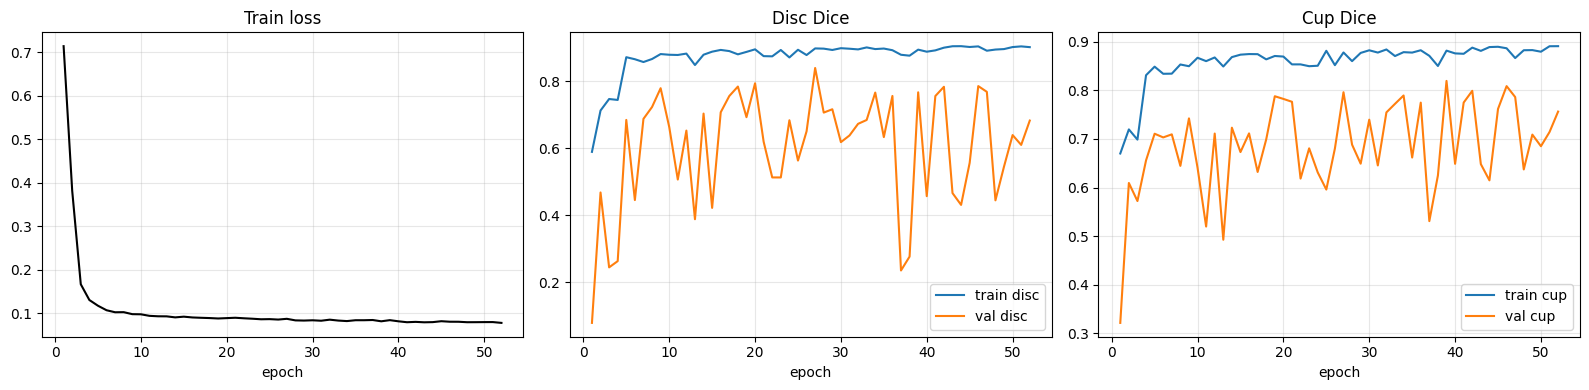

saved training_curves.png


In [ ]:
import matplotlib.pyplot as plt

def plot_curves(history, save="training_curves.png"):
    h = np.array(history)  # cols: ep, loss, td, tc, vd, vc, vm
    ep = h[:, 0]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(ep, h[:, 1], "k-"); ax[0].set_title("Train loss"); ax[0].set_xlabel("epoch"); ax[0].grid(alpha=.3)
    ax[1].plot(ep, h[:, 2], label="train disc"); ax[1].plot(ep, h[:, 4], label="val disc")
    ax[1].set_title("Disc Dice"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    ax[2].plot(ep, h[:, 3], label="train cup"); ax[2].plot(ep, h[:, 5], label="val cup")
    ax[2].set_title("Cup Dice"); ax[2].set_xlabel("epoch"); ax[2].legend(); ax[2].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(save, dpi=120, bbox_inches="tight"); plt.show()
    print("saved", save)

plot_curves(history)

## Cell 12 — Full labelled metric tables for **train / val / test**

Loads the best checkpoint and prints a clearly-labelled per-class table (Dice / IoU / Precision /
Recall / Accuracy for background, optic disc, optic cup) for **all three splits**, plus the
`mean(disc,cup)` for each. This is the "what Dice corresponds to what" table for the writeup.

In [ ]:
@torch.no_grad()
def full_metrics(model, loader, use_tta=False, use_pp=False):
    model.eval()
    agg = {c: {"dice": [], "iou": [], "prec": [], "rec": [], "acc": []} for c in range(cfg.NUM_CLASSES)}
    for img, mask in loader:
        img = img.to(DEVICE)
        prob = _tta_prob(model, img) if use_tta else F.softmax(model(img), 1)
        pr = prob.argmax(1).cpu().numpy()
        for b in range(img.size(0)):
            p = pr[b].copy(); gt = mask[b].numpy()
            if use_pp:
                disc = largest_cc_close((p >= 1).astype(np.uint8))
                cup  = (largest_cc_close((p == 2).astype(np.uint8)) & disc).astype(np.uint8)
                p = disc.copy(); p[cup == 1] = 2
            pt = torch.tensor(p); gtt = torch.tensor(gt)
            for c in range(cfg.NUM_CLASSES):
                s = class_stats(pt, gtt, c)
                for k in agg[c]: agg[c][k].append(s[k])
    return {c: {k: float(np.mean(v)) for k, v in d.items()} for c, d in agg.items()}

def print_split_table(name, m):
    names = ["Background", "Optic Disc", "Optic Cup"]
    print(f"\n===== {name} =====")
    print(f"{'Class':12s} {'Dice':>7s} {'IoU':>7s} {'Prec':>7s} {'Recall':>7s} {'Acc':>7s}")
    for c, nm in enumerate(names):
        d = m[c]; print(f"{nm:12s} {d['dice']:7.4f} {d['iou']:7.4f} {d['prec']:7.4f} {d['rec']:7.4f} {d['acc']:7.4f}")
    print(f"{'Mean(D+C)':12s} {(m[1]['dice']+m[2]['dice'])/2:7.4f}")
    return m

model.load_state_dict(torch.load(cfg.CKPT_PATH, map_location=DEVICE))
m_tr = print_split_table("TRAIN", full_metrics(model, train_loader))
m_va = print_split_table("VAL",   full_metrics(model, val_loader))
m_te = print_split_table("TEST (+TTA +PostProc)", full_metrics(model, test_loader, cfg.USE_TTA, cfg.USE_POSTPROC))


===== TRAIN =====
Class           Dice     IoU    Prec  Recall     Acc
Background    0.9992  0.9985  0.9996  0.9989  0.9985
Optic Disc    0.8969  0.8174  0.8605  0.9424  0.9975
Optic Cup     0.8753  0.7835  0.9108  0.8603  0.9989
Mean(D+C)     0.8861

===== VAL =====
Class           Dice     IoU    Prec  Recall     Acc
Background    0.9972  0.9945  0.9989  0.9956  0.9946
Optic Disc    0.8396  0.7381  0.8301  0.8716  0.9956
Optic Cup     0.7961  0.6970  0.7690  0.8984  0.9968
Mean(D+C)     0.8178

===== TEST (+TTA +PostProc) =====
Class           Dice     IoU    Prec  Recall     Acc
Background    0.9971  0.9943  0.9981  0.9961  0.9944
Optic Disc    0.7892  0.6983  0.7713  0.8182  0.9950
Optic Cup     0.7548  0.6695  0.7227  0.8063  0.9970
Mean(D+C)     0.7720


## Cell 13 — Qualitative visuals (fundus / GT / prediction / overlay)

Grid like the paper's Figs. 2–5: for N test samples, shows the fundus image, the ground-truth 3-class
mask, the predicted mask, and a coloured overlay (green = disc/rim, red = cup). Saves `qualitative.png`.

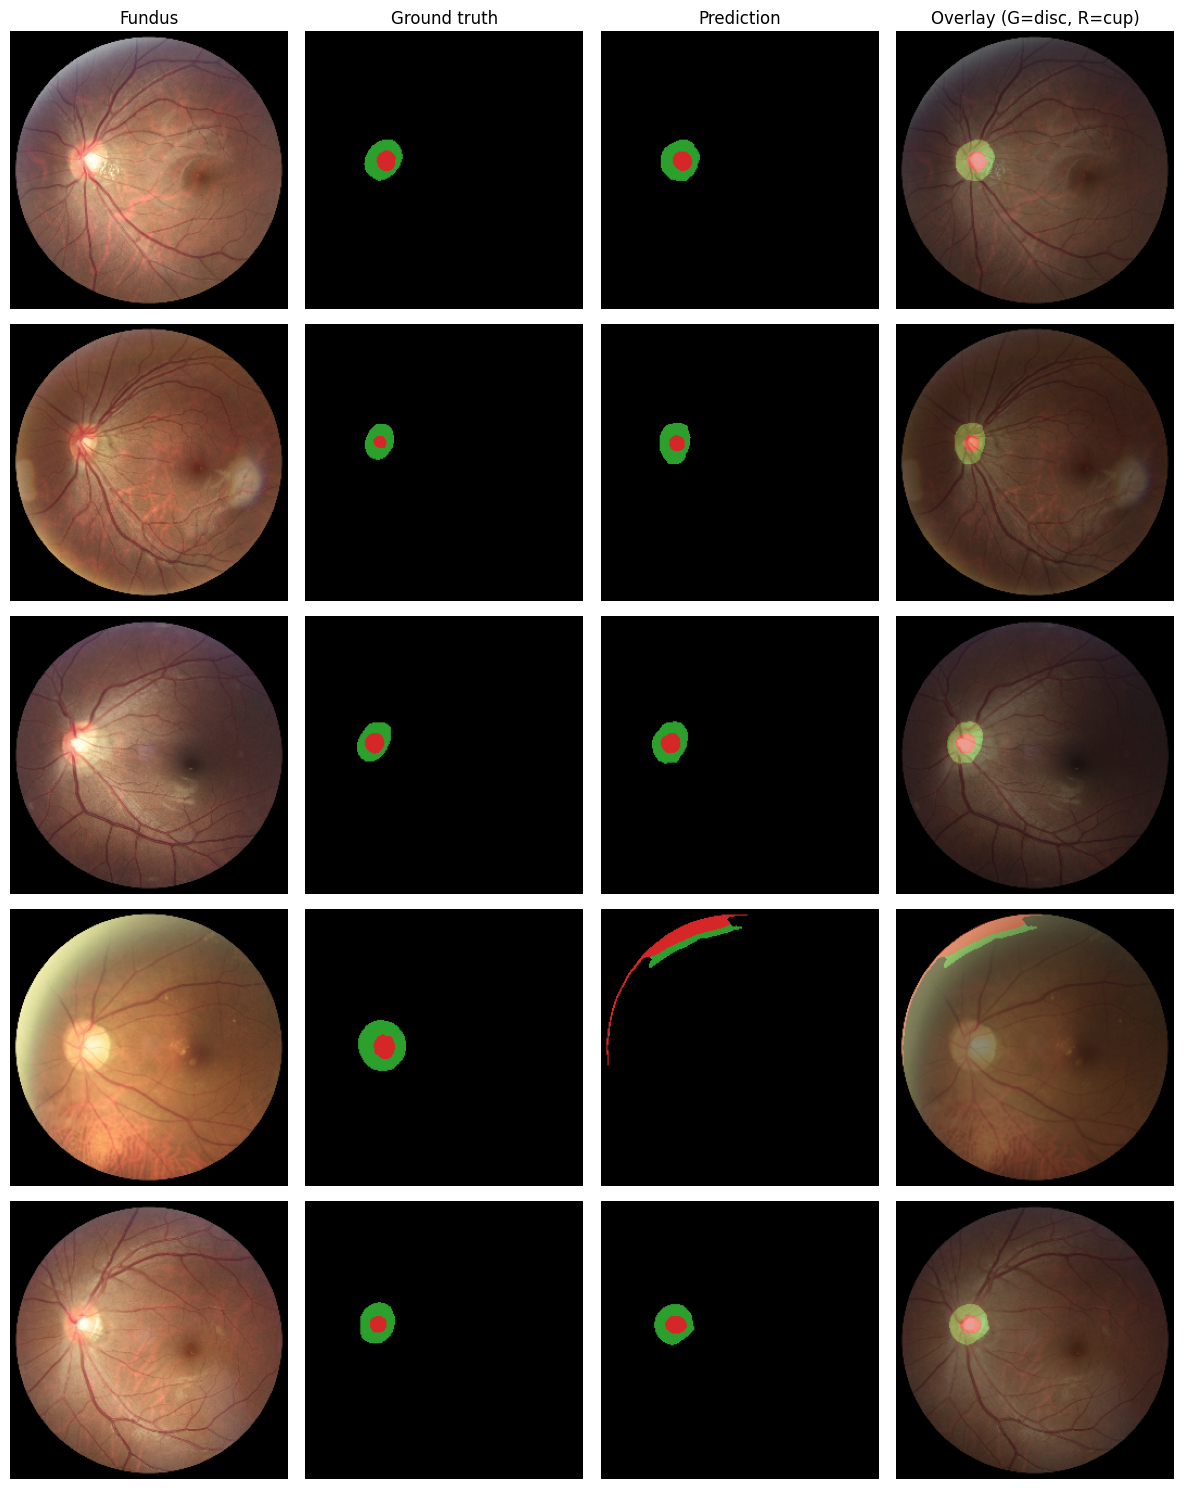

saved qualitative.png


In [ ]:
from matplotlib.colors import ListedColormap

CMAP = ListedColormap(["black", "#2ca02c", "#d62728"])   # bg, disc(green), cup(red)

def denorm(img):
    x = img * IMAGENET_STD + IMAGENET_MEAN
    return x.permute(1, 2, 0).clamp(0, 1).numpy()

@torch.no_grad()
def visualize(model, loader, n=5, use_tta=True, use_pp=True, save="qualitative.png"):
    model.eval()
    imgs, gts, preds = [], [], []
    for img, mask in loader:
        prob = _tta_prob(model, img.to(DEVICE)) if use_tta else F.softmax(model(img.to(DEVICE)), 1)
        pr = prob.argmax(1).cpu().numpy()
        for b in range(img.size(0)):
            p = pr[b].copy()
            if use_pp:
                disc = largest_cc_close((p >= 1).astype(np.uint8))
                cup  = (largest_cc_close((p == 2).astype(np.uint8)) & disc).astype(np.uint8)
                p = disc.copy(); p[cup == 1] = 2
            imgs.append(denorm(img[b])); gts.append(mask[b].numpy()); preds.append(p)
            if len(imgs) >= n: break
        if len(imgs) >= n: break
    fig, ax = plt.subplots(n, 4, figsize=(12, 3 * n))
    cols = ["Fundus", "Ground truth", "Prediction", "Overlay (G=disc, R=cup)"]
    for i in range(n):
        ax[i, 0].imshow(imgs[i])
        ax[i, 1].imshow(gts[i], cmap=CMAP, vmin=0, vmax=2)
        ax[i, 2].imshow(preds[i], cmap=CMAP, vmin=0, vmax=2)
        ax[i, 3].imshow(imgs[i]); ax[i, 3].imshow(preds[i], cmap=CMAP, vmin=0, vmax=2, alpha=0.45)
        for j in range(4):
            ax[i, j].axis("off")
            if i == 0: ax[i, j].set_title(cols[j])
    plt.tight_layout(); plt.savefig(save, dpi=120, bbox_inches="tight"); plt.show()
    print("saved", save)

visualize(model, test_loader, n=5)

## Cell 14 — Consolidated run summary (one block to copy into the report)

Prints a single tidy summary: config used, best val epoch, per-split mean(disc,cup), the test disc/cup/
RIM Dice and both clinical means, plus the comparison row vs your prior runs. Also writes `run_summary.txt`.

In [ ]:
def run_summary(cfg, best_val, m_tr, m_va, m_te, whole_rim_cup_test):
    wd, rd, cd = whole_rim_cup_test  # from Cell 10's evaluate_test
    lines = []
    a = lines.append
    a("="*64); a("CSP-KAN-UNet — RUN SUMMARY"); a("="*64)
    a(f"IMG_SIZE={cfg.IMG_SIZE}  KAN_DEPTH={cfg.KAN_DEPTH}  BOTT_DIM={cfg.BOTT_DIM}")
    a(f"Attention  Channel={cfg.USE_CHANNEL}  Spatial={cfg.USE_SPATIAL}  Pixel={cfg.USE_PIXEL}")
    a(f"Loss  {cfg.W_CE}CE + {cfg.W_DICE}Dice + {cfg.W_TVERSKY}FT | class_w={cfg.CLASS_WEIGHTS} | Tversky b={cfg.TVERSKY_BETA}")
    a(f"Best val mean(disc,cup) Dice = {best_val:.4f}")
    a("-"*64)
    a("mean(disc,cup) Dice per split:")
    a(f"   TRAIN {(m_tr[1]['dice']+m_tr[2]['dice'])/2:.4f} | VAL {(m_va[1]['dice']+m_va[2]['dice'])/2:.4f} "
      f"| TEST {(m_te[1]['dice']+m_te[2]['dice'])/2:.4f}")
    a("-"*64)
    a("TEST (fused 3-class, +TTA +PostProc):")
    a(f"   Whole-disc Dice = {wd:.4f}")
    a(f"   RIM Dice        = {rd:.4f}")
    a(f"   Cup Dice        = {cd:.4f}")
    a(f"   Mean(whole-disc, cup) = {(wd+cd)/2:.4f}   (target 0.90)")
    a(f"   Mean(rim,        cup) = {(rd+cd)/2:.4f}   (target 0.90)")
    a("-"*64)
    a("Comparison (REFUGE 256, test):")
    a(f"   Conv Y-Net            whole 0.9618 | cup 0.8491 | mean 0.9055")
    a(f"   KAN-bottleneck Y-Net  whole 0.9374 | cup 0.8083 | mean 0.8729")
    a(f"   CSP-KAN-UNet (this)   whole {wd:.4f} | cup {cd:.4f} | mean {(wd+cd)/2:.4f}")
    a("="*64)
    txt = "\n".join(lines); print(txt)
    open("run_summary.txt", "w").write(txt); print("\nsaved run_summary.txt")

# To produce the summary, run Cell 12 (m_tr/m_va/m_te) and grab whole/rim/cup from Cell 10, then:
rows = evaluate_test(model, test_loader, cfg.USE_TTA, cfg.USE_POSTPROC)
wrc = (np.mean(rows['whole']), np.mean(rows['rim']), np.mean(rows['cup']))
run_summary(cfg, best_val, m_tr, m_va, m_te, wrc)

CSP-KAN-UNet — RUN SUMMARY
IMG_SIZE=256  KAN_DEPTH=2  BOTT_DIM=512
Attention  Channel=True  Spatial=True  Pixel=True
Loss  0.4CE + 0.3Dice + 0.3FT | class_w=[1.0, 1.0, 1.5] | Tversky b=0.7
Best val mean(disc,cup) Dice = 0.8178
----------------------------------------------------------------
mean(disc,cup) Dice per split:
   TRAIN 0.8861 | VAL 0.8178 | TEST 0.7720
----------------------------------------------------------------
TEST (fused 3-class, +TTA +PostProc):
   Whole-disc Dice = 0.8594
   RIM Dice        = 0.7892
   Cup Dice        = 0.7548
   Mean(whole-disc, cup) = 0.8071   (target 0.90)
   Mean(rim,        cup) = 0.7720   (target 0.90)
----------------------------------------------------------------
Comparison (REFUGE 256, test):
   Conv Y-Net            whole 0.9618 | cup 0.8491 | mean 0.9055
   KAN-bottleneck Y-Net  whole 0.9374 | cup 0.8083 | mean 0.8729
   CSP-KAN-UNet (this)   whole 0.8594 | cup 0.7548 | mean 0.8071

saved run_summary.txt
